In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore")


In [2]:
# Load Ragasa and Yagi station locations, then classify overlap.
ROOT = Path.cwd()
if not (ROOT / "input" / "weather_station_location.xlsx").exists():
    ROOT = Path("Fig1")

INPUT_XLSX = ROOT / "input" / "weather_station_location.xlsx"
OUT_DIR = ROOT / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def read_station_sheet(sheet_name: str) -> pd.DataFrame:
    """Read one no-header sheet as station code, latitude, longitude."""
    df = pd.read_excel(
        INPUT_XLSX,
        sheet_name=sheet_name,
        header=None,
        names=["code", "lat", "lon"],
    )
    df["code"] = df["code"].astype(str).str.strip().str.upper()
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df = df.dropna(subset=["code", "lat", "lon"]).drop_duplicates("code")
    return df.reset_index(drop=True)


ragasa = read_station_sheet("Ragasa")
yagi = read_station_sheet("Yagi")

ragasa_codes = set(ragasa["code"])
yagi_codes = set(yagi["code"])

both_codes = ragasa_codes & yagi_codes
ragasa_only_codes = ragasa_codes - yagi_codes
yagi_only_codes = yagi_codes - ragasa_codes

both = ragasa[ragasa["code"].isin(both_codes)].copy()
ragasa_only = ragasa[ragasa["code"].isin(ragasa_only_codes)].copy()
yagi_only = yagi[yagi["code"].isin(yagi_only_codes)].copy()

stations_all = (
    pd.concat(
        [
            both.assign(category="Both"),
            ragasa_only.assign(category="Ragasa only"),
            yagi_only.assign(category="Yagi only"),
        ],
        ignore_index=True,
    )
    .sort_values(["lat", "lon", "code"])
    .reset_index(drop=True)
)

print(f"Both ({len(both_codes)}): {', '.join(sorted(both_codes))}")
print(f"Ragasa only ({len(ragasa_only_codes)}): {', '.join(sorted(ragasa_only_codes))}")
print(f"Yagi only ({len(yagi_only_codes)}): {', '.join(sorted(yagi_only_codes))}")


Both (26): CCH, CP1, GI, HKA, HKO, HKS, JKB, KP, LFS, NLS, NP, PEN, PLC, SC, SE, SF, SHA, SHL, SKG, TKL, TME, TMS, TMT, WGL, WLP, YTS
Ragasa only (4): NGP, SEK, SLW, TPK
Yagi only (5): BHD, CCB, LAM, TC, TUN


In [3]:
# Plot settings and Hong Kong map extent, matching the original station-location figure.
DPI = 600
FONT_SIZE = 12
FONT_FAMILY = "Arial" if "Arial" in {f.name for f in font_manager.fontManager.ttflist} else "DejaVu Sans"

mpl.rcParams.update(
    {
        "font.family": FONT_FAMILY,
        "font.size": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
        "legend.fontsize": 10,
    }
)

lat_min, lat_max, lon_min, lon_max = (22.139, 22.562, 113.824, 114.417)


[Saved] e:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig1\output\weather_stations.tif


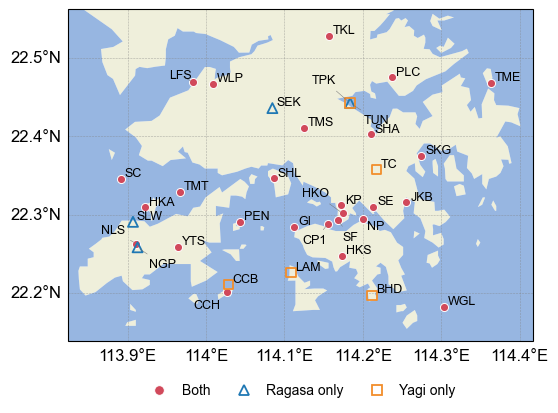

In [4]:
# Plot station locations: shared stations, Ragasa-only stations, and Yagi-only stations.
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND.with_scale("10m"))
ax.add_feature(cfeature.OCEAN.with_scale("10m"))

proj = ccrs.PlateCarree()
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, color="gray", alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12, "family": FONT_FAMILY}
gl.ylabel_style = {"size": 12, "family": FONT_FAMILY}

styles = {
    "Both": {
        "marker": "o",
        "s": 34,
        "facecolor": "#d1495b",
        "edgecolor": "white",
        "linewidth": 0.7,
        "zorder": 3,
    },
    "Ragasa only": {
        "marker": "^",
        "s": 52,
        "facecolor": "none",
        "edgecolor": "#1f78b4",
        "linewidth": 1.3,
        "zorder": 5,
    },
    "Yagi only": {
        "marker": "s",
        "s": 45,
        "facecolor": "none",
        "edgecolor": "#f28e2b",
        "linewidth": 1.3,
        "zorder": 6,
    },
}

for category in ["Both", "Ragasa only", "Yagi only"]:
    sub = stations_all[stations_all["category"] == category]
    style = styles[category]
    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=style["s"],
        marker=style["marker"],
        facecolors=style["facecolor"],
        edgecolors=style["edgecolor"],
        linewidths=style["linewidth"],
        transform=proj,
        zorder=style["zorder"],
    )

# Match the original logic: most labels are placed just beside the marker;
# only crowded labels are manually offset, with short leader lines where needed.
custom_offsets = {
    "NLS": (-8, 5),
    "NGP": (8, -8),
    "HKO": (-10, 10),
    "LFS": (-1, 1),
    "NP": (3, -1),
    "CP1": (-1, -8),
    "SF": (3, -8),
    "CCH": (-5, -5),
    "TPK": (-10, 12),
    "TUN": (10, -8),
}

arrow_stations = {"NLS", "NGP", "HKO", "LFS", "NP", "CP1", "SF", "TPK", "TUN"}

for _, row in stations_all.iterrows():
    station_name = row["code"]

    if station_name in custom_offsets:
        offset_x, offset_y = custom_offsets[station_name]
        ha = "left" if offset_x >= 0 else "right"
        va = "bottom" if offset_y >= 0 else "top"
        ax.annotate(
            station_name,
            xy=(row["lon"], row["lat"]),
            xytext=(offset_x, offset_y),
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=9,
            fontfamily=FONT_FAMILY,
            arrowprops={"arrowstyle": "-", "color": "0.45", "lw": 0.35}
            if station_name in arrow_stations
            else None,
            transform=proj,
            zorder=7,
        )
    else:
        ax.text(
            row["lon"] + 0.005,
            row["lat"] + 0.003,
            station_name,
            fontsize=9,
            fontfamily=FONT_FAMILY,
            transform=proj,
            zorder=7,
        )

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=styles[label]["marker"],
        linestyle="None",
        markerfacecolor=styles[label]["facecolor"],
        markeredgecolor=styles[label]["edgecolor"],
        markeredgewidth=styles[label]["linewidth"],
        markersize=7,
        label=label,
    )
    for label in ["Both", "Ragasa only", "Yagi only"]
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.09),
    ncol=3,
    frameon=False,
    prop={"family": FONT_FAMILY, "size": 10},
    handletextpad=0.6,
    columnspacing=1.4,
)

out_tif = OUT_DIR / "weather_stations.tif"

fig.savefig(
    out_tif,
    dpi=DPI,
    format="tiff",
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"},
)

print(f"[Saved] {out_tif}")
plt.show()
